# 6. Modelos de Regressão

Este notebook explora diferentes modelos de regressão para análise de dados, incluindo Regressão Linear e Lasso, utilizando técnicas de pré-processamento como transformação Box-Cox e seleção de variáveis. O objetivo é avaliar o desempenho dos modelos em termos de métricas como RMSE e R², tanto nos datasets completos quanto após a remoção de outliers das questões do Enem (vetorizadas).


In [2]:
# Importando Dependências para Modelos de Regressão
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm

from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split

In [3]:
# Leitura dos dados
enem_data = pd.read_pickle("../data/final/enem_data_embeddings.pkl")
enem_data.head()

,numero_questao,enunciado,alternativas,gabarito,ano,gabarito_texto,distratores,enunciado_tokens,gabarito_tokens,distratores_tokens,dificuldade,enunciado_embbedings_word2vec,gabarito_embbedings_word2vec,distratores_embbedings_word2vec
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,2009,"reduzir o desmatamento, mantendo-se, assim, o ...",reduzir o calor irradiado pela Terra mediante ...,atmosfera terrestre composta gases nitrogênio ...,reduzir desmatamento mantendo assim potencial ...,reduzir calor irradiado terra mediante substit...,-1.70677,"[-0.0016308315, -0.057879616, -0.085349284, 0....","[0.007537251, -0.049133625, 0.11472875, -0.115...","[0.03476311, -0.035221867, -0.00517779, -0.128..."
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,2009,Estimativa de tempo necessário para metaboliza...,Concentração média de álcool no sangue ao long...,analise figura supondo necessário dar título f...,estimativa tempo necessário metabolizar difere...,concentração média álcool sangue longo dia var...,0.62043,"[-0.026465332, -0.030027837, 0.028988913, 0.14...","[0.07856357, -0.022353431, -0.12115115, 0.0183...","[0.0763594, -0.11076818, 0.0048947046, 0.04739..."
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,2009,"induzir a imunidade, para proteger o organismo...",ser capaz de alterar o genoma do organismo por...,estima atualmente mundo milhões pessoas infect...,induzir imunidade proteger organismo contamina...,capaz alterar genoma organismo portador induzi...,2.07704,"[0.027941352, 0.008942129, 0.08566157, 0.02149...","[0.097563, -0.0034619968, 0.08206, -0.109324, ...","[0.03503356, -0.010700853, 0.008868624, -0.027..."
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,2009,os genótipos idênticos e os fenótipos diferentes.,os genótipos e os fenótipos idênticos.; difere...,experimento preparou conjunto plantas técnica ...,genótipos idênticos fenótipos diferentes,genótipos fenótipos idênticos diferenças genót...,0.11500,"[-0.027700324, -0.014135911, -0.03359886, -0.0...","[0.098122, 0.0499915, -0.214217, -0.0571225, -...","[0.0143338675, -0.014280667, -0.21914314, 0.08..."
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,2009,"Kepler apresentou uma teoria científica que, g...","Ptolomeu apresentou as ideias mais valiosas, p...",linha tradição antiga astrônomo grego ptolomeu...,kepler apresentou teoria científica graças mét...,ptolomeu apresentou ideias valiosas serem anti...,0.21694,"[-0.027011229, 0.023866067, -0.08451317, 0.043...","[-0.031293802, 0.018204402, -0.0655475, 0.0612...","[-0.0040200884, 0.03563236, -0.038875517, 0.06..."


---

## 6.1. Regressão Linear


### 6.1.1. Dataset Completo


In [5]:
# Coletando os dados
X = [np.array(embedding) for embedding in enem_data["enunciado_embbedings_word2vec"]]
y = enem_data["dificuldade"]

In [6]:
# Aplicando Transformações
add_list = [(y.min() * (-1)) + 1] * len(y)
y = y + add_list

# Aplicando Boxcox
y, _ = stats.boxcox(y)

In [7]:
# Separando em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
# Adicionando constante
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [9]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     1.212
Date:                Mon, 28 Apr 2025   Prob (F-statistic):              0.111
Time:                        13:15:41   Log-Likelihood:                -32.417
No. Observations:                 423   AIC:                             666.8
Df Residuals:                     122   BIC:                             1885.
Df Model:                         300                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4370      0.879      1.635      0.1

### 6.1.2. Seleção de Variáveis


In [10]:
variables = [
    6,
    25,
    34,
    36,
    59,
    64,
    67,
    68,
    106,
    108,
    112,
    116,
    129,
    131,
    140,
    146,
    176,
    180,
    196,
    197,
    242,
    244,
    256,
    263,
    270,
    280,
    287,
    289,
    290,
    294,
]

In [11]:
# Criando novo conjunto de dados com as variáveis selecionadas
new_X = []

for i in range(len(X)):
    new_obs = []

    for index in variables:
        new_obs.append(float(X[i][int(index - 1)]))

    new_X.append(new_obs)

In [12]:
# Separando em conjunto de treino e teste
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(
    new_X, y, test_size=0.3, random_state=42
)

In [13]:
# Adicionando constante b0
new_X_train = sm.add_constant(new_X_train)
new_X_test = sm.add_constant(new_X_test)

In [14]:
# Treinando o modelo de Regressão Linear
new_model = sm.OLS(new_y_train, new_X_train).fit()
print(new_model.summary(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     2.777
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           3.61e-06
Time:                        13:15:46   Log-Likelihood:                -283.77
No. Observations:                 423   AIC:                             629.5
Df Residuals:                     392   BIC:                             755.0
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9912      0.143     13.904      0.0

### 6.1.3. Comparando Modelos

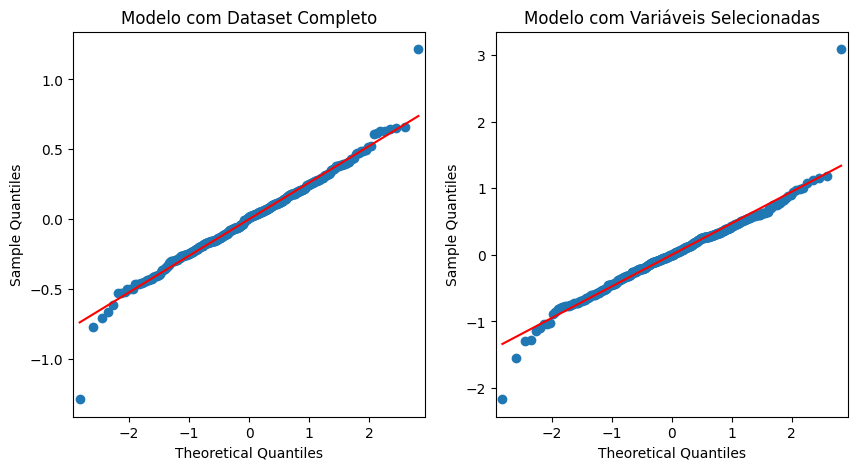

In [15]:
# Comparando os modelos
out_test = model.resid
out_test2 = new_model.resid

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sm.qqplot(out_test, line="s", ax=axes[0])
axes[0].set_title("Modelo com Dataset Completo")

sm.qqplot(out_test2, line="s", ax=axes[1])
axes[1].set_title("Modelo com Variáveis Selecionadas")

plt.show()

In [ ]:
# Comparando RMSE de cada modelo
pred1 = model.predict(X_test)
pred2 = new_model.predict(new_X_test)

rms1 = root_mean_squared_error(y_test, pred1)
rms2 = root_mean_squared_error(y_test, pred2)

print("RMSE com todas as variáveis:", rms1, "\nRMSE com variáveis escolhidas: ", rms2)

RMSE com todas as variaveis: 0.9761726951842663 
RMSE com variaveis escolhidas:  0.5283106806286871


### 6.1.4. Modelo com Corte (-3,3)


In [17]:
enem_filtered = enem_data.copy()
enem_filtered = enem_filtered[
    (enem_filtered["dificuldade"] >= -3) & (enem_filtered["dificuldade"] <= 3)
]
enem_filtered["dificuldade"].describe()

count    591.000000
mean       1.281414
std        0.768053
min       -1.800920
25%        0.777885
50%        1.372000
75%        1.819295
max        2.992980
Name: dificuldade, dtype: float64

In [19]:
# Preparando covariáveis
X = []
for vet in enem_filtered["enunciado_embbedings_word2vec"]:
    X.append(np.array(vet))

In [ ]:
y = enem_filtered["dificuldade"]
add_list = [(y.min() * (-1)) + 1] * len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]

array([0.09750886, 4.39471297, 8.70694246])

In [21]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [22]:
# Adicionando constante
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [23]:
model = sm.OLS(y_train, X_train).fit()
pred = model.predict(X_test)

rms = root_mean_squared_error(y_test, pred)

print("RMSE com todas as variaveis:", rms)

RMSE com todas as variaveis: 3.8836268218548113


In [24]:
print(model.summary(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1.492
Date:                Mon, 28 Apr 2025   Prob (F-statistic):            0.00718
Time:                        15:45:46   Log-Likelihood:                -584.18
No. Observations:                 413   AIC:                             1770.
Df Residuals:                     112   BIC:                             2981.
Df Model:                         300                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4459      4.218      1.054      0.2

### 6.1.6. Selecionando Variáveis

In [25]:
variables = [
    30,
    39,
    59,
    60,
    68,
    76,
    98,
    129,
    143,
    170,
    175,
    179,
    182,
    210,
    221,
    224,
    232,
    288,
]

In [26]:
new_X = []
for i in range(len(X)):
    new_obs = []
    for index in variables:
        new_obs.append(float(X[i][int(index - 1)]))
    new_X.append(new_obs)

In [ ]:
# Dividindo os dados em treino e teste
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(
    new_X, y, test_size=0.3, random_state=42
)

In [ ]:
# Adicionando constante
new_X_train = sm.add_constant(new_X_train)
new_X_test = sm.add_constant(new_X_test)

In [29]:
new_model = sm.OLS(new_y_train, new_X_train).fit()
pred = new_model.predict(new_X_test)

rms = root_mean_squared_error(new_y_test, pred)

print("RMSE com as variaveis escolhidas:", rms)

RMSE com as variaveis escolhidas: 2.0241948595956676


In [30]:
print(new_model.summary(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     2.913
Date:                Mon, 28 Apr 2025   Prob (F-statistic):           7.01e-05
Time:                        15:47:15   Log-Likelihood:                -890.63
No. Observations:                 413   AIC:                             1819.
Df Residuals:                     394   BIC:                             1896.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9622      0.538      9.222      0.0

---
## 6.2. Regressão Lasso


### 6.2.1. Dataset Completo


In [31]:
X = []
for vet in enem_data["enunciado_embbedings_word2vec"]:
    X.append(np.array(vet))

In [32]:
y = enem_data["dificuldade"]
add_list = [(y.min() * (-1)) + 1] * len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]


array([0.09250241, 1.83513762, 2.67640292])

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [34]:
model_lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=0).fit(
    X_train, y_train
)
pred_lasso = model_lasso.predict(X_test)

print("melhor r2 score (treino):", model_lasso.score(X_train, y_train))
print("r2 score (teste):", model_lasso.score(X_test, y_test))
print("melhor alpha:", model_lasso.alpha_)
print("RMSE com o alpha escolhido:", root_mean_squared_error(y_test, pred_lasso))

melhor r2 score (treino): 0.2943528462555647
r2 score (teste): -0.00902111126338756
melhor alpha: 0.001
RMSE com o alpha escolhido: 0.5107711437163239


### 6.2.2. Modelo com Corte (-3, 3)


In [35]:
enem_filtered = enem_data.copy()
enem_filtered = enem_filtered[
    (enem_filtered["dificuldade"] >= -3) & (enem_filtered["dificuldade"] <= 3)
]
enem_filtered["dificuldade"].describe()

count    591.000000
mean       1.281414
std        0.768053
min       -1.800920
25%        0.777885
50%        1.372000
75%        1.819295
max        2.992980
Name: dificuldade, dtype: float64

In [36]:
X = []
for vet in enem_filtered["enunciado_embbedings_word2vec"]:
    X.append(np.array(vet))

In [ ]:
y = enem_filtered["dificuldade"]
add_list = [(y.min() * (-1)) + 1] * len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]

array([0.09750886, 4.39471297, 8.70694246])

In [38]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [47]:
model_lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10, 100], random_state=0, tol=0.1).fit(
    X_train, y_train
)
pred_lasso = model_lasso.predict(X_test)

print("melhor r2 score (treino):", model_lasso.score(X_train, y_train))
print("r2 score (teste):", model_lasso.score(X_test, y_test))
print("melhor alpha:", model_lasso.alpha_)
print("RMSE com o alpha escolhido:", root_mean_squared_error(y_test, pred_lasso))

melhor r2 score (treino): 0.11916915027399466
r2 score (teste): 0.08955075904467147
melhor alpha: 0.01
RMSE com o alpha escolhido: 1.9332350644870202
